In [1]:
import numpy as np
import pandas as pd
import gudhi as gd
import sklearn
import matplotlib
import gudhi.representations
from sklearn import manifold
from sklearn.datasets import make_circles
from pylab import *
from matplotlib import pyplot as plt
from PIL import Image
from matplotlib import cm
import cv2
import sklearn
import torch
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

C:\Users\aczer\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tmp = np.load('np_topo.npy')

In [3]:
tmp.shape

(50000, 1, 500)

In [4]:
# data = sklearn.datasets.fetch_openml(name='CIFAR_10_small')#, version=1)
transform = transforms.Compose(
    [transforms.ToTensor()])#,
     # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

Files already downloaded and verified


In [5]:
# image.tolist()

In [6]:
image = trainset.data[1]
img = Image.fromarray(image)

In [7]:
image.shape

(32, 32, 3)

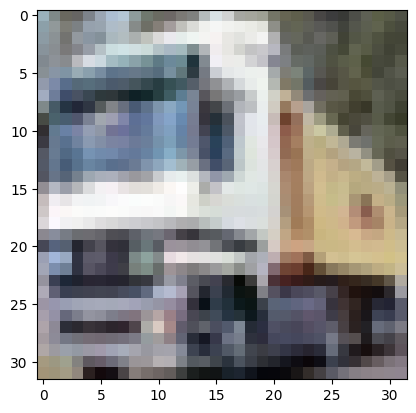

In [8]:
# plt.imshow(np.transpose(image, (1, 2, 0)))
plt.imshow(image)
plt.show()

In [9]:
gray_scale_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
to_grayscale = transforms.Grayscale(num_output_channels=1)
bw_image = to_grayscale(img)

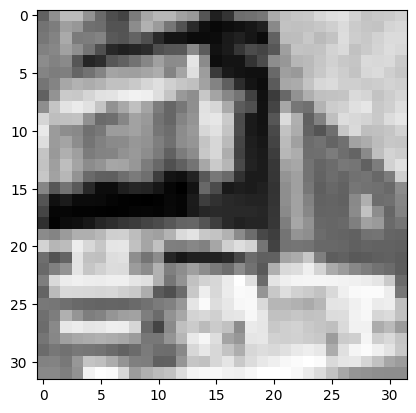

In [10]:
plt.imshow(gray_scale_img,cmap = 'Greys')
plt.show()

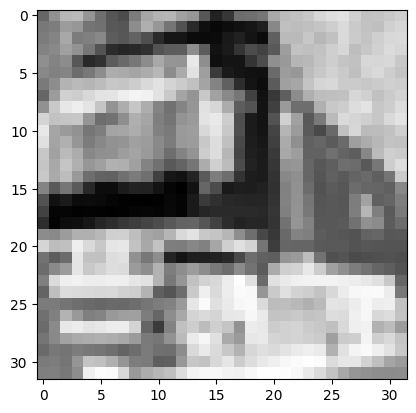

In [11]:
plt.imshow(bw_image,cmap = 'Greys')
plt.show()

In [12]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [13]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [14]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

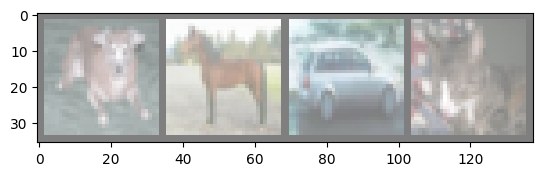

dog   horse car   cat  


In [15]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [16]:
tmp_img = images[1]

In [17]:
tmp_img.shape

torch.Size([3, 32, 32])

In [18]:
to_grayscale = transforms.Grayscale(num_output_channels=1)
bw_image = to_grayscale(tmp_img)

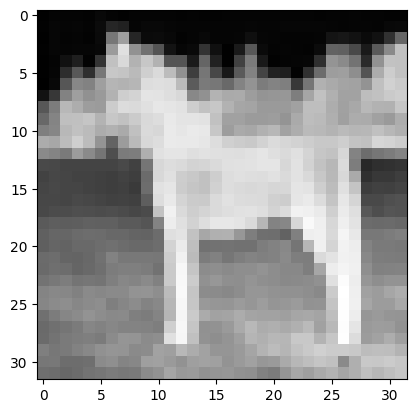

In [19]:
plt.imshow(np.transpose(bw_image, (1, 2, 0)),cmap = 'Greys')

In [20]:
bw_image[0].shape

torch.Size([32, 32])

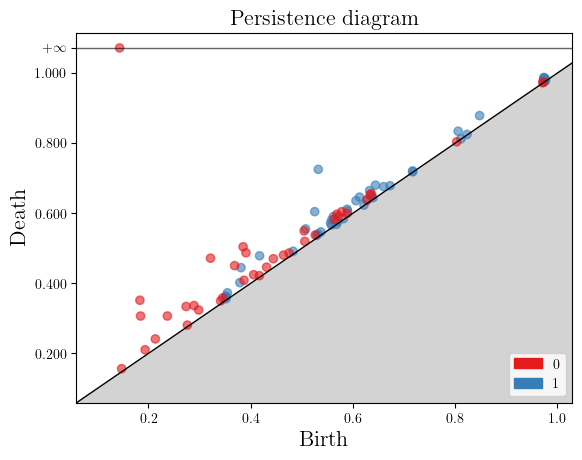

In [21]:
# Normalize pixel intensities (optional)

# normalized_image = bw_image[0] / np.max(bw_image[0])

# Step 2: Create a CubicalComplex
# bw_img_2 = 
cubical_complex = gd.CubicalComplex(dimensions=bw_image.shape, top_dimensional_cells=bw_image.flatten())

# Step 3: Compute persistent homology
diag = cubical_complex.persistence()

# Step 4: Visualize the persistence diagram
gd.plot_persistence_diagram(diag)
plt.show()

In [25]:
cubical_complex.persistence_intervals_in_dimension(0)

array([[0.14747646, 0.15632197],
       [0.19344315, 0.21030001],
       [0.21337609, 0.24124709],
       [0.27613336, 0.28073022],
       [0.18452039, 0.30654866],
       [0.23690394, 0.30663335],
       [0.2982353 , 0.32382825],
       [0.27354592, 0.33384591],
       [0.28909373, 0.33651099],
       [0.34111375, 0.34980828],
       [0.18317178, 0.35156158],
       [0.34520394, 0.35820669],
       [0.38683766, 0.40857649],
       [0.41701728, 0.42174783],
       [0.40571845, 0.42443019],
       [0.43098041, 0.44591492],
       [0.36853686, 0.45033219],
       [0.44432038, 0.46998084],
       [0.32132551, 0.47161844],
       [0.46408904, 0.4803898 ],
       [0.47484946, 0.48627493],
       [0.39057142, 0.48707378],
       [0.38509101, 0.50420159],
       [0.50579613, 0.5195412 ],
       [0.52627844, 0.53767967],
       [0.50449729, 0.54950321],
       [0.56386435, 0.58261847],
       [0.57222044, 0.59065413],
       [0.56840825, 0.596793  ],
       [0.58863026, 0.59922165],
       [0.

Text(0.5, 1.0, 'Persistence Image')

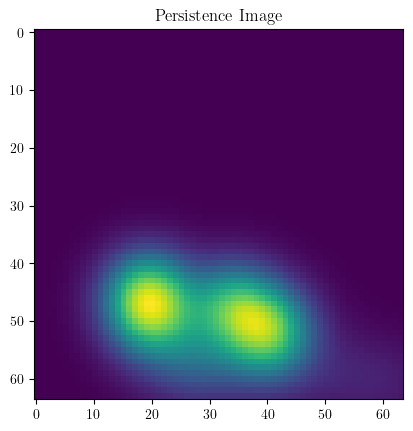

In [27]:
PI = gd.representations.PersistenceImage(bandwidth=0.05,resolution=[64,64],weight=lambda x: x[1]**2, im_range=[0,0.6,0,0.6])#(bandwidth=1e-4, weight=lambda x: x[1]**2, \
                                         # im_range=[0,.0004,0,.0004], resolution=[2,2])
pi = PI.fit_transform([cubical_complex.persistence_intervals_in_dimension(0)[:-1]])
tmp = np.reshape(pi[0], [1,64,64])
plt.imshow(np.flip(tmp[0], 0))
plt.title("Persistence Image")

In [141]:
PI_0 = PI.fit_transform([cubical_complex.persistence_intervals_in_dimension(0)[:-1]])
L_t_0 = torch.tensor(PI_0,dtype=torch.float)
PI_1 = PI.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])
L_t_1 = torch.tensor(PI_1,dtype=torch.float)
L_t = torch.vstack([L_t_0,L_t_1])

In [154]:
L_t_0.reshape([1,64,64]).shape

torch.Size([1, 64, 64])

In [121]:
bandwidth

0.12

In [116]:
# diagrams = diag
# diagrams
diagrams[1]
tmp = [d[1][0] for d in diagrams]
all_birth = np.array([d[1][0] for d in diagrams])
all_death = np.array([d[1][1] for d in diagrams])
persistence_range = all_death.max() - all_birth.min()
bandwidth = persistence_range / 5

In [117]:
cubical_complex.persistence_intervals_in_dimension(0)[:-1].max()

0.6779831647872925

Text(0.5, 1.0, 'Persistence Image')

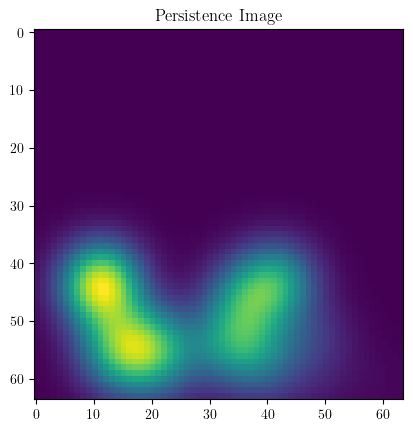

In [118]:
plt.imshow(np.flip(np.reshape(pi[0], [64,64]), 0))
plt.title("Persistence Image")

In [22]:
BC = gd.representations.vector_methods.BettiCurve()
BC_1 = BC.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])

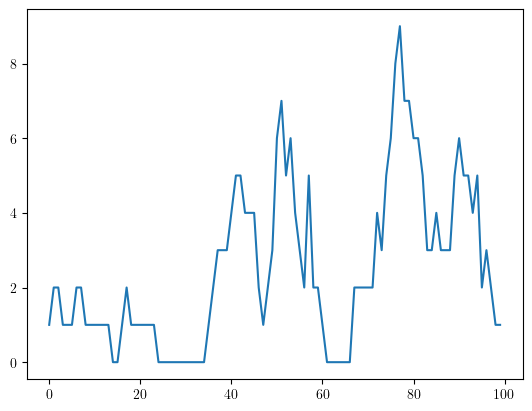

In [27]:
plt.plot(BC_1[0])
plt.show()

In [28]:
LS = gd.representations.vector_methods.BettiCurve(resolution=100)
L = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(0)[:-1]])
L_t = torch.tensor(L,dtype=torch.float)

In [29]:
L_t.shape

torch.Size([1, 100])

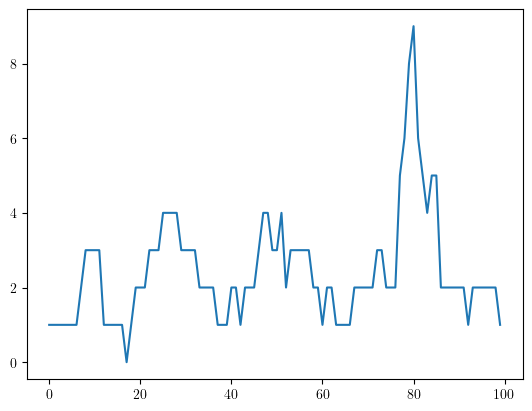

In [30]:
plt.plot(L[0])
# plt.plot(BC_1[0])

In [33]:
plt.imshow(np.flip(np.reshape(pi[0], [32,32]), 0))
plt.title("Persistence Image")

TypeError: 'float' object is not subscriptable

In [28]:
LS = gd.representations.Landscape(resolution=200)
L = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])

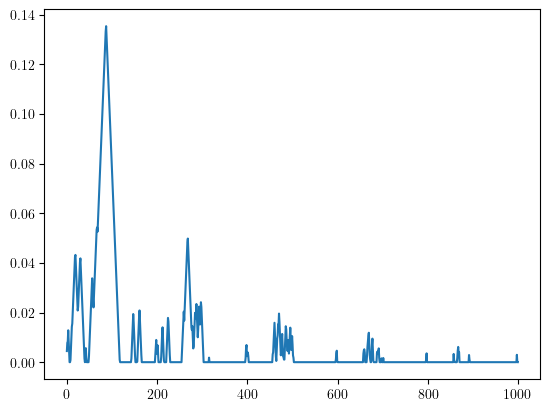

In [31]:
L.shape
plt.plot(L[0])

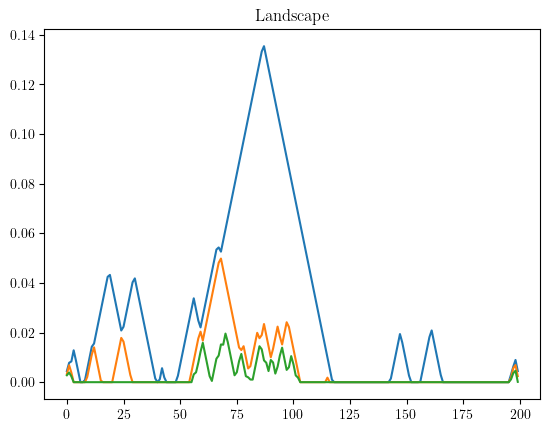

In [30]:
plt.plot(L[0][:200])
plt.plot(L[0][200:400])
plt.plot(L[0][400:600])
plt.title("Landscape")
plt.show()

In [189]:
L.shape

(1, 500)

In [41]:
LS = gd.representations.vector_methods.ComplexPolynomial()
L = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])

In [44]:
L[0]

array([-2.99651719e+01-3.09696508e+01j, -3.01698554e+01+9.14178177e+02j,
        9.44885551e+03-8.55646594e+03j, -1.30909637e+05-8.66298123e+03j,
        6.87294067e+05+8.11466604e+05j,  7.00641589e+05-7.03475708e+06j,
       -3.10821356e+07+2.45993413e+07j,  1.89628204e+08+2.52866173e+07j,
       -4.79523991e+08-6.49264128e+08j, -4.97860668e+08+2.97206254e+09j])

In [57]:
LS = gd.representations.vector_methods.Entropy(resolution = 100)
L = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])

In [58]:
L

array([[3.77246844]])

In [ ]:
gudhi.representations.kernel_methods.SlicedWassersteinKernel

In [75]:
LS = gd.representations.vector_methods.Silhouette()
L = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(0)[:-1]])

In [77]:
LS = gd.representations.vector_methods.Silhouette()
L_2 = LS.fit_transform([cubical_complex.persistence_intervals_in_dimension(1)])

In [78]:
L_0 = torch.tensor(L)
L_1 = torch.tensor(L_2)

In [81]:
L_t = torch.cat([L_0,L_1],dim=1)

In [82]:
L_t.shape

torch.Size([1, 200])